<a href="https://colab.research.google.com/github/AdityaCypherX/AdityaCypherX/blob/main/India_job_market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [5]:
df= pd.read_csv("india_job_market_dataset.csv")
df

,Job ID,Job Title,Company Name,Job Location,Job Type,Salary Range,Experience Required,Posted Date,Application Deadline,Job Portal,Number of Applicants,Education Requirement,Skills Required,Remote/Onsite,Company Size
0,JOB1,Software Engineer,Amazon,Ahmedabad,Full-time,5-8 LPA,2-5 years,2025-01-16,2025-01-25,LinkedIn,23,PhD,"C++, SQL, Python",Remote,Small (1-50)
1,JOB2,Marketing Executive,Infosys,Ahmedabad,Internship,5-8 LPA,2-5 years,2024-12-25,2025-01-19,Indeed,462,MBA,"SQL, C++, Python",Remote,Large (500+)
2,JOB3,Financial Analyst,Deloitte,Jaipur,Contract,20+ LPA,5-10 years,2025-01-22,2025-01-29,Naukri.com,430,M.Tech,"Machine Learning, Excel, React",Remote,Large (500+)
3,JOB4,Business Analyst,Amazon,Delhi,Full-time,20+ LPA,2-5 years,2025-01-07,2025-02-06,LinkedIn,387,B.Tech,"Machine Learning, Python, SQL",Hybrid,Small (1-50)
4,JOB5,Software Engineer,Infosys,Delhi,Full-time,12-20 LPA,10+ years,2024-12-26,2025-01-08,Indeed,199,MBA,"UI/UX, C++, Java",Onsite,Small (1-50)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,JOB19996,Marketing Executive,Deloitte,Pune,Full-time,5-8 LPA,2-5 years,2025-01-13,2025-02-05,Indeed,171,PhD,"Machine Learning, Python, AWS",Remote,Small (1-50)
19996,JOB19997,Business Analyst,Accenture,Bangalore,Internship,20+ LPA,0-2 years,2025-01-08,2025-01-27,LinkedIn,482,MBA,"Digital Marketing, React, Machine Learning",Onsite,Medium (51-500)
19997,JOB19998,Graphic Designer,Wipro,Jaipur,Part-time,5-8 LPA,5-10 years,2024-12-26,2025-01-16,Naukri.com,319,PhD,"Machine Learning, Excel, Digital Marketing",Onsite,Small (1-50)
19998,JOB19999,Sales Representative,Infosys,Kolkata,Internship,12-20 LPA,2-5 years,2025-01-20,2025-02-09,Naukri.com,178,M.Tech,"Excel, C++, React",Onsite,Large (500+)


### What are the most in demand job roles?

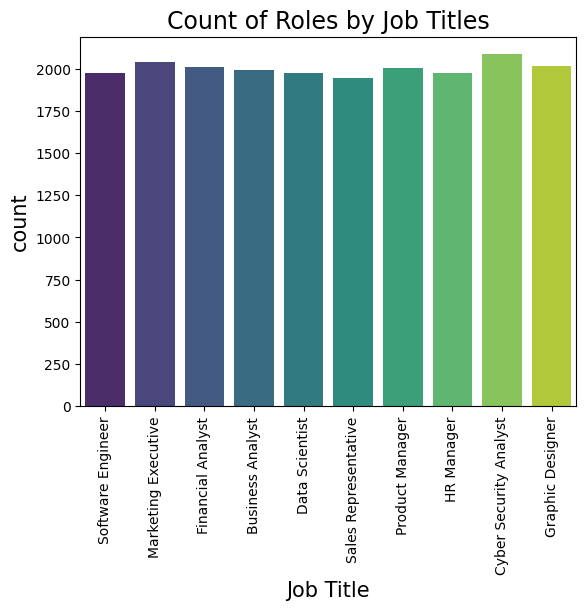

In [17]:
sns.countplot(x = "Job Title", data=df,hue="Job Title",palette='viridis')
plt.xticks(rotation = 90)
plt.xlabel("Job Title", fontsize=15)
plt.ylabel("count",fontsize=15)
plt.title("Count of Roles by Job Titles",fontsize=17,color="black")
plt.show()

# Which companies are posting the most job openings?

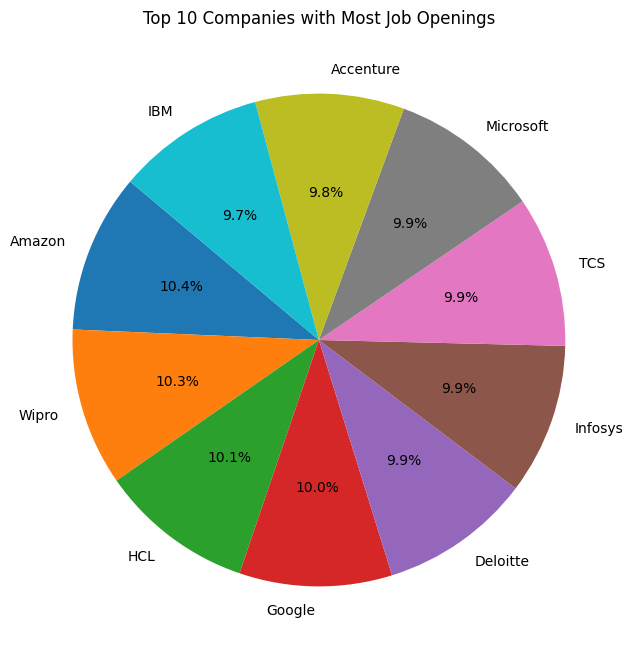

In [19]:
company_counts = df['Company Name'].value_counts()
top_companies = company_counts.head(10)
top_companies_percentages = top_companies / top_companies.sum() * 100
plt.figure(figsize=(8, 8))
plt.pie(top_companies_percentages, labels=top_companies.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Companies with Most Job Openings')
plt.show()

# What is the distribution of job types?


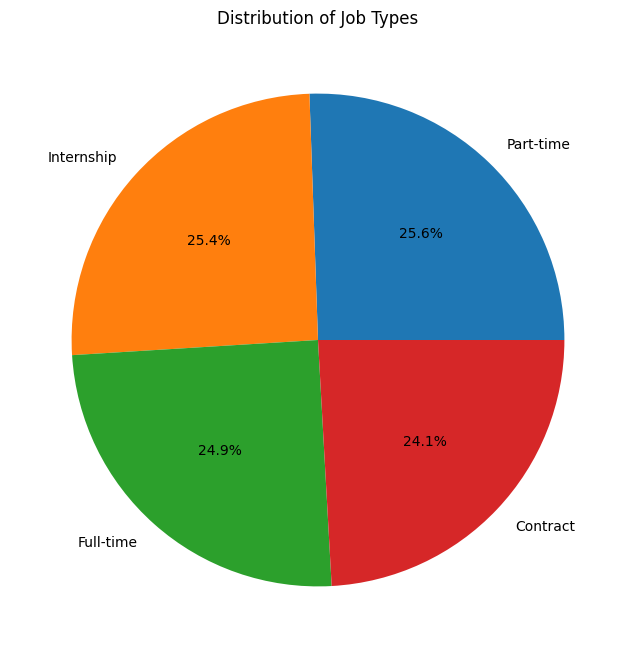

In [21]:
job_type_counts = df['Job Type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(job_type_counts, labels=job_type_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Job Types')
plt.show()

Salary and Experience Analysis:


# 1.What is the distribution of salary ranges across different job roles?



# What is the average experience required for different job types?

<ipython-input-35-5dafe37f106e>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_experience, x='Experience Required', y='Job Type', palette='viridis')


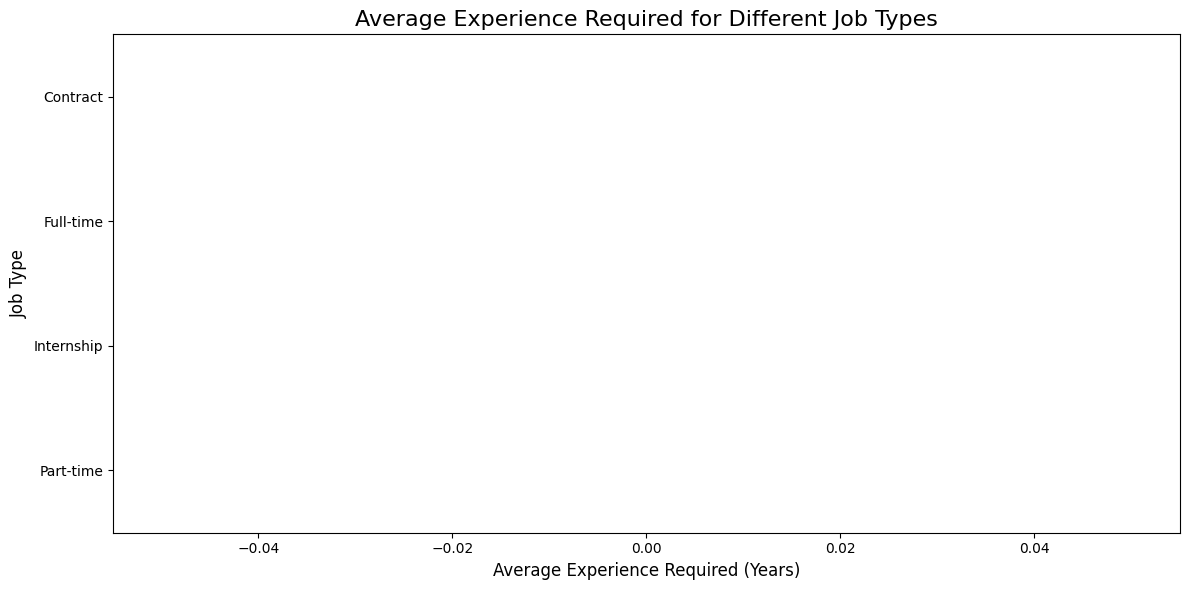

In [35]:
def convert_experience(experience):
    if pd.isna(experience):
        return None  # Handle missing values
    experience = str(experience)  # Ensure it's treated as a string
    if "0-2 years" in experience:
        return 1
    elif "2-5 years" in experience:
        return 3.5
    elif "5-10 years" in experience:
        return 7.5
    elif "10+ years" in experience:
        return 10
    else:
        return None  # Handle unexpected values

# Apply the conversion to the column
df['Experience Required'] = df['Experience Required'].apply(convert_experience)

# Grouping the data by 'Job Type' and calculating the average experience required
average_experience = df.groupby('Job Type')['Experience Required'].mean().reset_index()
average_experience = average_experience.sort_values(by='Experience Required', ascending=False)

# Horizontal Bar Plot (best visualization)
plt.figure(figsize=(12, 6))
sns.barplot(data=average_experience, x='Experience Required', y='Job Type', palette='viridis')
plt.title('Average Experience Required for Different Job Types', fontsize=16)
plt.xlabel('Average Experience Required (Years)', fontsize=12)
plt.ylabel('Job Type', fontsize=12)
plt.tight_layout()
plt.show()

# Which salary range has the highest number of job postings?

The salary range with the highest number of job postings is: 12-20 LPA with 4066 postings.


<ipython-input-36-464ed851345b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


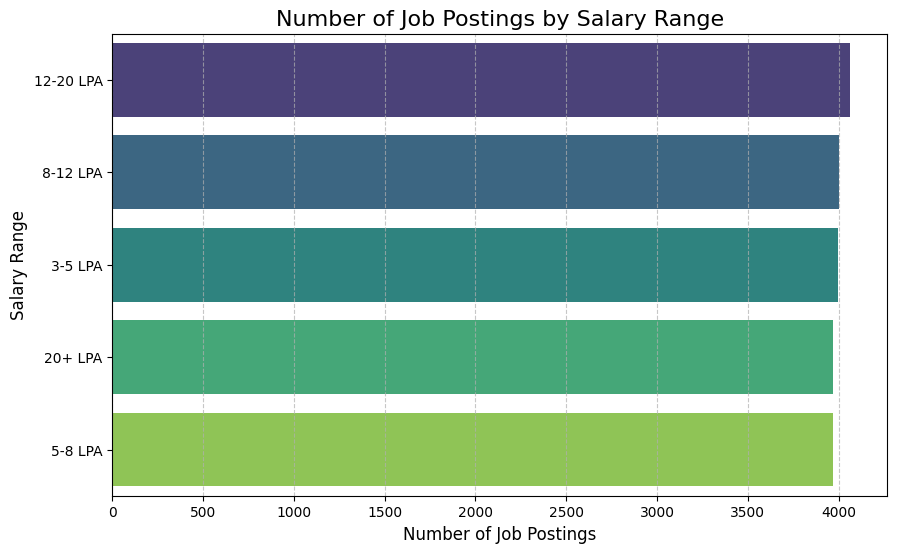

In [36]:
salary_range_counts = df['Salary Range'].value_counts()

# Finding the salary range with the highest number of postings
max_salary_range = salary_range_counts.idxmax()
max_count = salary_range_counts.max()

print(f"The salary range with the highest number of job postings is: {max_salary_range} with {max_count} postings.")

# Visualization: Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x=salary_range_counts.values,
    y=salary_range_counts.index,
    palette="viridis"
)
plt.title("Number of Job Postings by Salary Range", fontsize=16)
plt.xlabel("Number of Job Postings", fontsize=12)
plt.ylabel("Salary Range", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

Location Insights:
# Which cities have the highest number of job opportunities?

<ipython-input-37-2addd30fc550>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


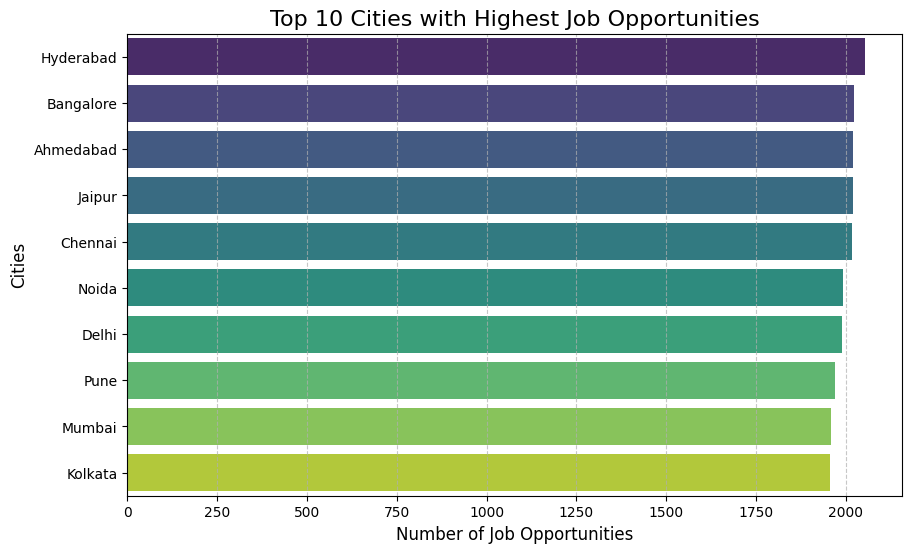

In [37]:

# Group by 'Job Location' and get the count of job opportunities
location_insights = df['Job Location'].value_counts().head(10)  # Top 10 cities with the highest number of jobs

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    x=location_insights.values,
    y=location_insights.index,
    palette="viridis"
)
plt.title("Top 10 Cities with Highest Job Opportunities", fontsize=16)
plt.xlabel("Number of Job Opportunities", fontsize=12)
plt.ylabel("Cities", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# What are the most common job types in each location?

   Job Location    Job Type  Count
3     Ahmedabad   Part-time    525
6     Bangalore  Internship    550
11      Chennai   Part-time    547
14        Delhi  Internship    503
17    Hyderabad   Full-time    531
22       Jaipur  Internship    521
25      Kolkata   Full-time    510
31       Mumbai   Part-time    530
34        Noida  Internship    502
38         Pune  Internship    505


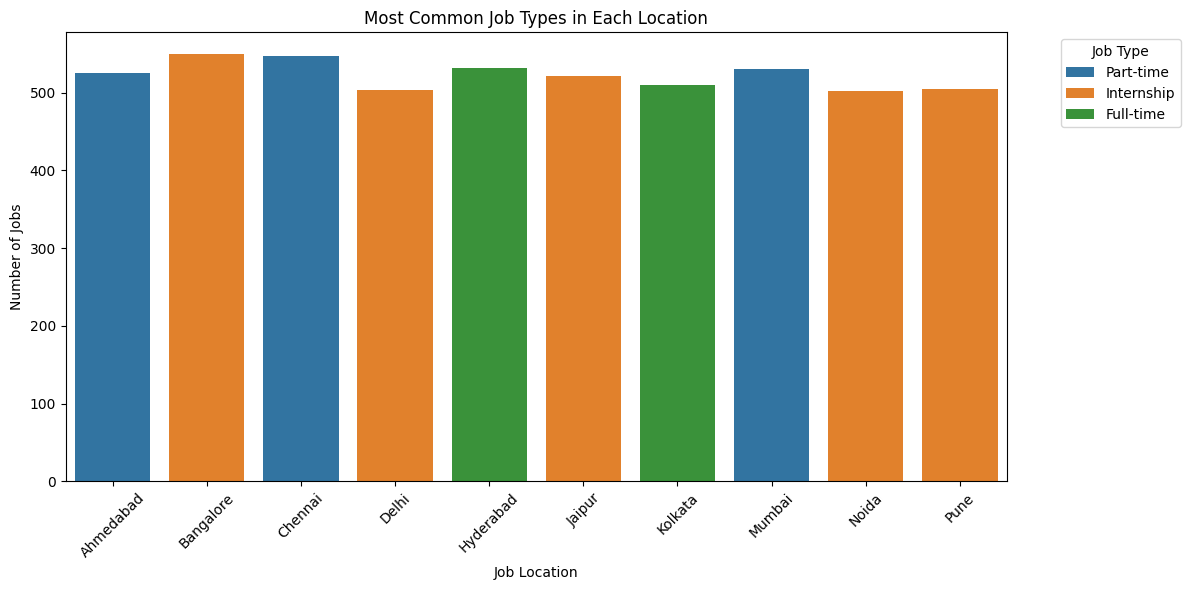

In [38]:
location_job_counts = df.groupby(['Job Location', 'Job Type']).size().reset_index(name='Count')

# Find the most common job type in each location
most_common_jobs = location_job_counts.loc[location_job_counts.groupby('Job Location')['Count'].idxmax()]

# Print the results
print(most_common_jobs)

# Visualization: Bar plot for the most common job types in each location
plt.figure(figsize=(12, 6))
sns.barplot(data=most_common_jobs, x='Job Location', y='Count', hue='Job Type')
plt.title('Most Common Job Types in Each Location')
plt.xlabel('Job Location')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.legend(title='Job Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Skills and Education Analysis:
# Which skills are most frequently required in job postings?

<ipython-input-46-a8effc4dd47b>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')


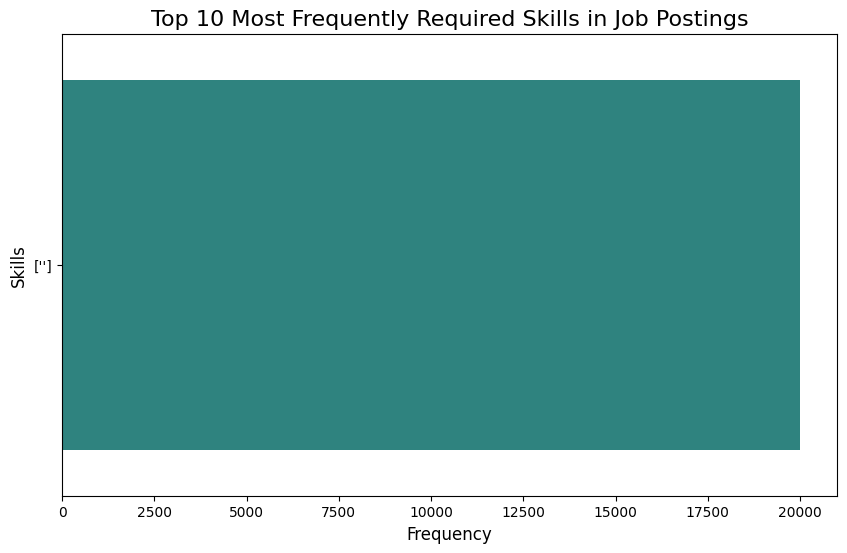

In [46]:
df['Skills Required'] = df['Skills Required'].fillna('').astype(str)

# Split the 'Skills Required' column into a list of skills
df['Skills Required'] = df['Skills Required'].str.split(',')

# Explode the lists of skills into individual rows
skills_series = df['Skills Required'].explode().str.strip()

# Count the frequency of each skill
skills_frequency = skills_series.value_counts()

# Select the top 10 most frequently required skills
top_skills = skills_frequency.head(10)

# Visualization: Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')
plt.title('Top 10 Most Frequently Required Skills in Job Postings', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Skills', fontsize=12)
plt.show()

# What is the correlation between educational qualifications and salary ranges?

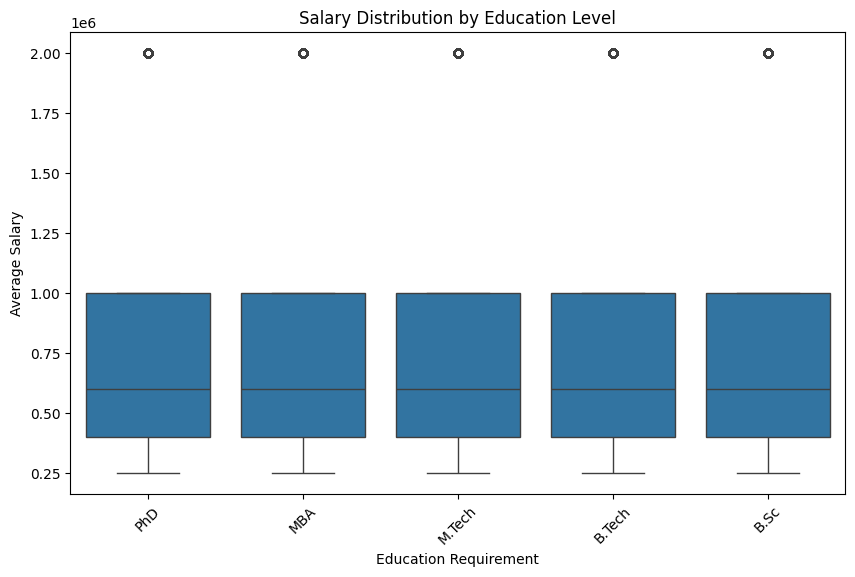

In [50]:
def clean_salary_range(salary_str):
    # Handle cases like '20+ LPA', '15k-30k', '10000-20000', etc.
    salary_str = str(salary_str).replace(" LPA", "00000")  # Convert LPA to a 5-digit number
    salary_str = salary_str.replace("k", "000")  # Convert 'k' to 000
    salary_str = salary_str.replace("+", "")  # Remove '+' signs

    # Extract numeric values
    salary_range = re.findall(r'\d+', salary_str)

    if len(salary_range) == 1:
        return float(salary_range[0])  # If only one value, return it
    elif len(salary_range) == 2:
        return (float(salary_range[0]) + float(salary_range[1])) / 2  # Return average for two values
    return None  # Return None if the format is not recognized

# Assuming df is the DataFrame already loaded
df['Average Salary'] = df['Salary Range'].apply(clean_salary_range)

# Convert Education Requirement to categorical values
education_map = {
    "PhD": 4,
    "Master's": 3,
    "Bachelor's": 2,
    "Diploma": 1
}
df['Education Numeric'] = df['Education Requirement'].map(education_map)

# Correlation between Education and Salary (numeric values)
correlation = df[['Education Numeric', 'Average Salary']].corr()

# Visualizing the correlation with a Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Education Requirement', y='Average Salary')
plt.title('Salary Distribution by Education Level')
plt.xticks(rotation=45)
plt.show()

# Which education level is most demanded for different job roles?

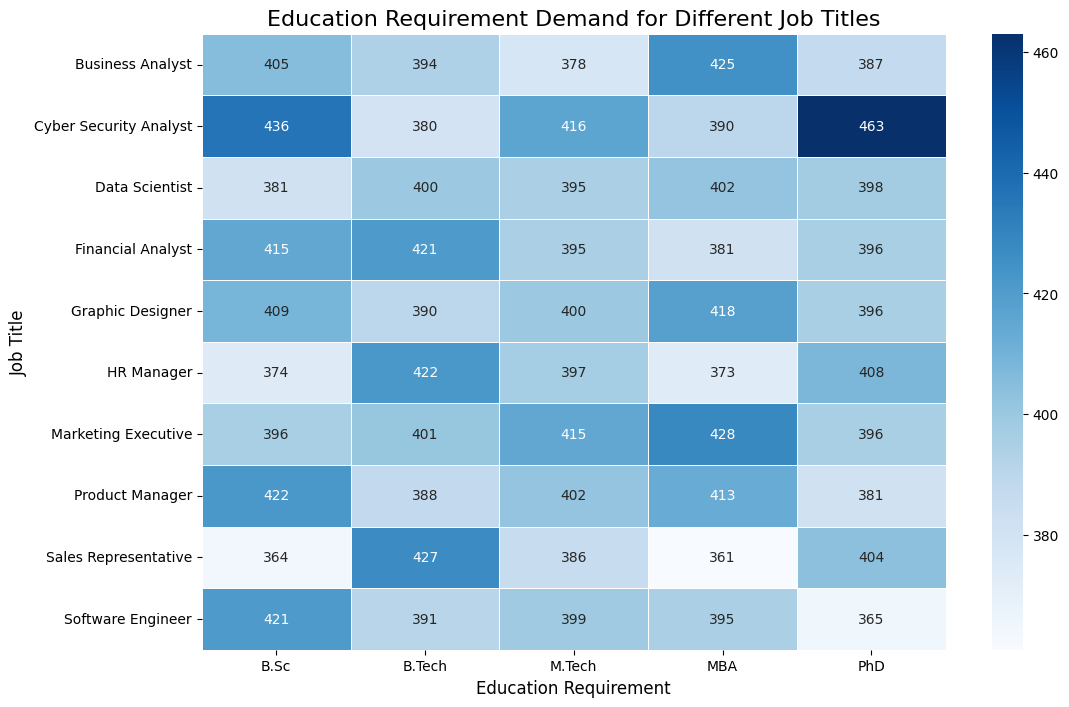

In [52]:
education_job_group = df.groupby(['Job Title', 'Education Requirement']).size().reset_index(name='Count')

# Pivot the table for a heatmap visualization
pivot_data = education_job_group.pivot(index='Job Title', columns='Education Requirement', values='Count')

# Create a heatmap to visualize the education demand per job title
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, cmap='Blues', fmt='d', linewidths=0.5)
plt.title("Education Requirement Demand for Different Job Titles", fontsize=16)
plt.xlabel("Education Requirement", fontsize=12)
plt.ylabel("Job Title", fontsize=12)
plt.show()

Hiring Timeline:
# How does the number of job postings vary by month? (Line chart of postings over time)

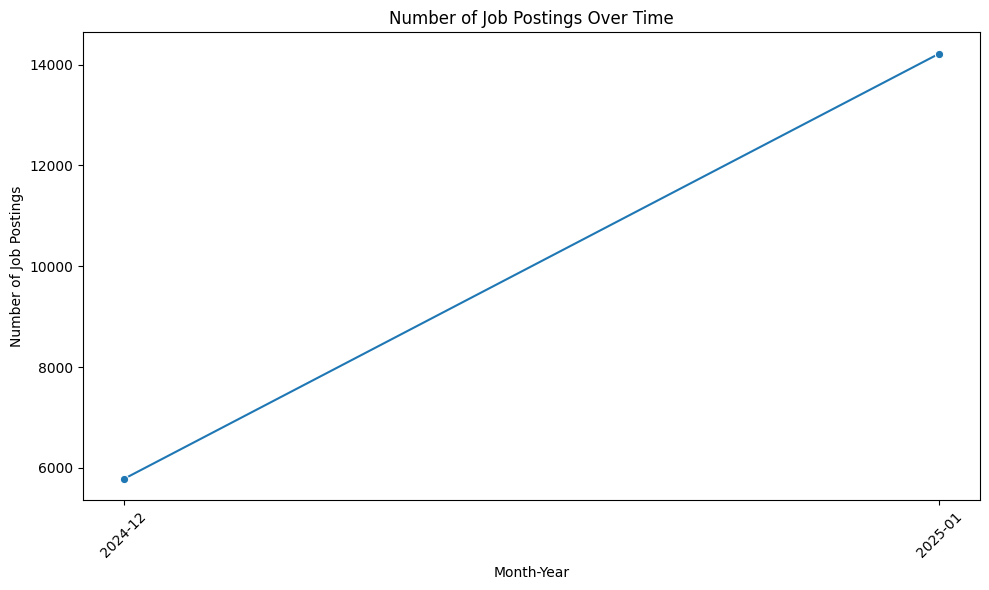

In [54]:
df['Posted Date'] = pd.to_datetime(df['Posted Date'], errors='coerce')

# Extract month and year from 'Posted Date'
df['Month_Year'] = df['Posted Date'].dt.to_period('M')

# Convert 'Month_Year' to string for proper plotting
df['Month_Year'] = df['Month_Year'].astype(str)

# Count job postings per month
job_postings_by_month = df.groupby('Month_Year').size().reset_index(name='Postings')

# Set up the plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month_Year', y='Postings', data=job_postings_by_month, marker='o')

# Customize the plot
plt.title('Number of Job Postings Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

# What is the average duration between job posting and application deadline? (Histogram)

Average Duration: 18.55915 days


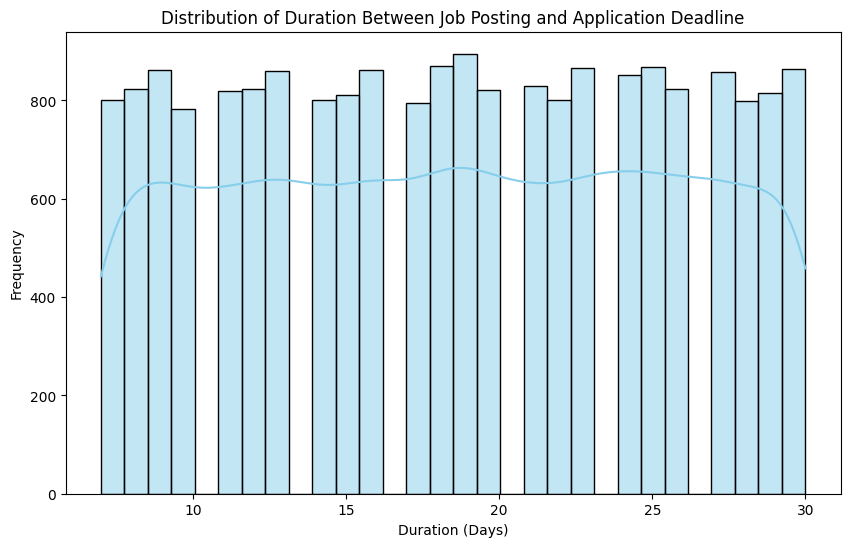

In [55]:
df['Posted Date'] = pd.to_datetime(df['Posted Date'])
df['Application Deadline'] = pd.to_datetime(df['Application Deadline'])

# Calculate the difference between the application deadline and posted date
df['Duration'] = (df['Application Deadline'] - df['Posted Date']).dt.days

# Calculate the average duration
average_duration = df['Duration'].mean()
print(f"Average Duration: {average_duration} days")

# Plot histogram of the duration
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Duration Between Job Posting and Application Deadline')
plt.xlabel('Duration (Days)')
plt.ylabel('Frequency')
plt.show()

Application Trends:
# Which job portals are attracting the highest number of applicants?

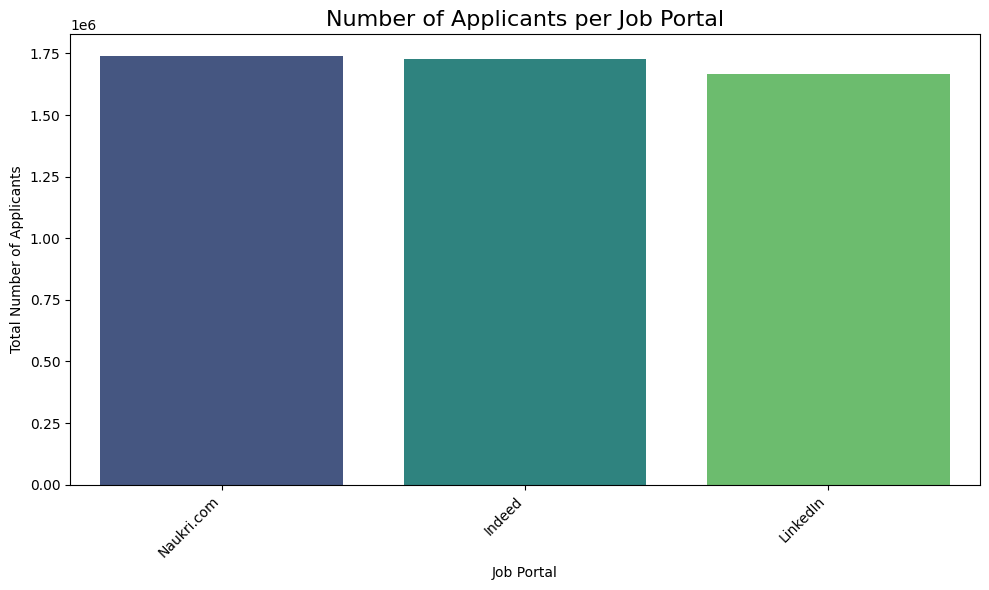

In [57]:
portal_applicants = df.groupby('Job Portal')['Number of Applicants'].sum().reset_index()

# Sort the data in descending order to get the portals with the highest number of applicants
portal_applicants = portal_applicants.sort_values(by='Number of Applicants', ascending=False)

# Visualization using Seaborn barplot for better clarity
plt.figure(figsize=(10, 6))
sns.barplot(data=portal_applicants, x='Job Portal', y='Number of Applicants', hue='Job Portal', palette='viridis')
plt.title('Number of Applicants per Job Portal', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Number of Applicants')
plt.xlabel('Job Portal')
plt.tight_layout()
plt.show()

# Which job titles receive the most applications

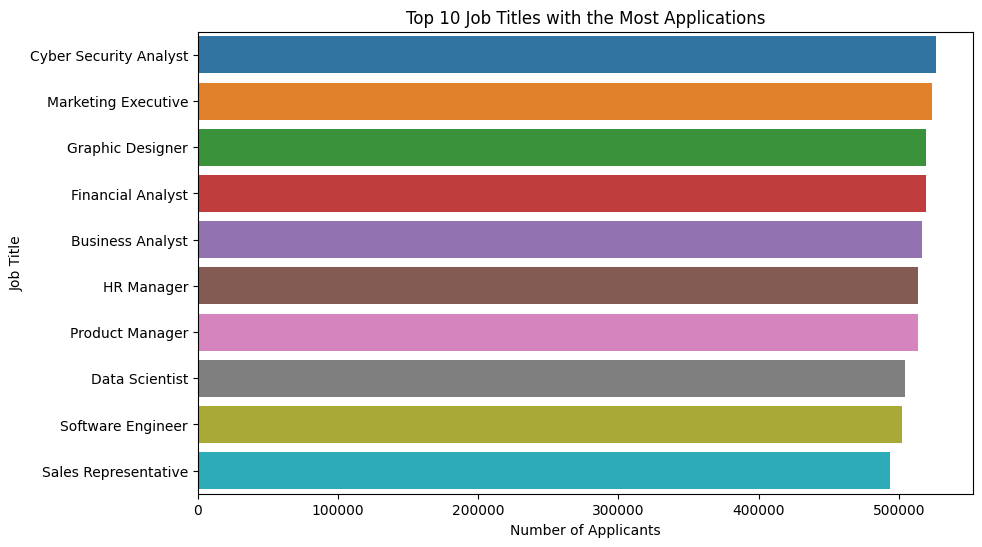

In [59]:
job_title_applications = df.groupby('Job Title')['Number of Applicants'].sum().reset_index()

# Step 2: Sort the values in descending order to find the job titles with the most applications
job_title_applications_sorted = job_title_applications.sort_values(by='Number of Applicants', ascending=False)

# Step 3: Visualization

# Create a bar plot with job titles and the number of applicants
plt.figure(figsize=(10, 6))
sns.barplot(x='Number of Applicants', y='Job Title', data=job_title_applications_sorted.head(10), hue='Job Title', legend=False)
plt.title('Top 10 Job Titles with the Most Applications')
plt.xlabel('Number of Applicants')
plt.ylabel('Job Title')
plt.show()

Company Analysis:
# What is the distribution of job postings by company size?

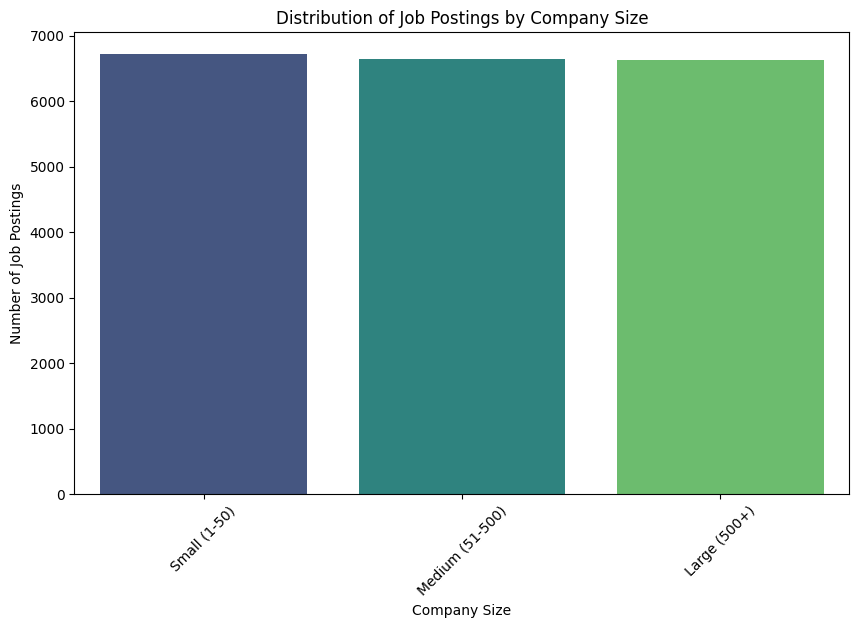

In [61]:
company_size_distribution = df['Company Size'].value_counts()

# Bar plot with 'hue' assignment to avoid future warning
plt.figure(figsize=(10, 6))
sns.barplot(x=company_size_distribution.index, y=company_size_distribution.values, hue=company_size_distribution.index, palette="viridis", legend=False)
plt.title('Distribution of Job Postings by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.show()


# Which companies offer the most remote work opportunities?

<ipython-input-64-124d0e5d9b5e>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies_remote.values, y=top_companies_remote.index, palette='viridis')


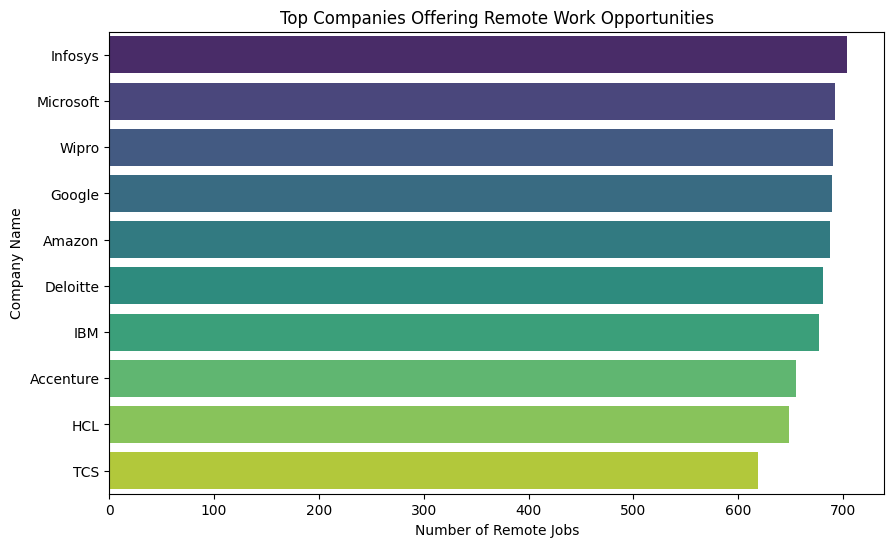

In [64]:

# Filter the dataset for remote opportunities
remote_jobs = df[df['Remote/Onsite'] == 'Remote']

# Count remote opportunities by company
remote_job_counts = remote_jobs['Company Name'].value_counts()

# Select top N companies with the most remote opportunities
top_companies_remote = remote_job_counts.head(10)

# Visualization: Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_companies_remote.values, y=top_companies_remote.index, palette='viridis')
plt.title('Top Companies Offering Remote Work Opportunities')
plt.xlabel('Number of Remote Jobs')
plt.ylabel('Company Name')
plt.legend([],[], frameon=False)  # This hides the legend
plt.show()